In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
#Load processed dataset
df = pd.read_csv("../../data/processed/spam_processed.csv")

spam_df = df[df["label"] == 1]
ham_df  = df[df["label"] == 0]

print(f"Total: {len(df)} | Spam: {len(spam_df)} | Ham: {len(ham_df)}")

Total: 5169 | Spam: 653 | Ham: 4516


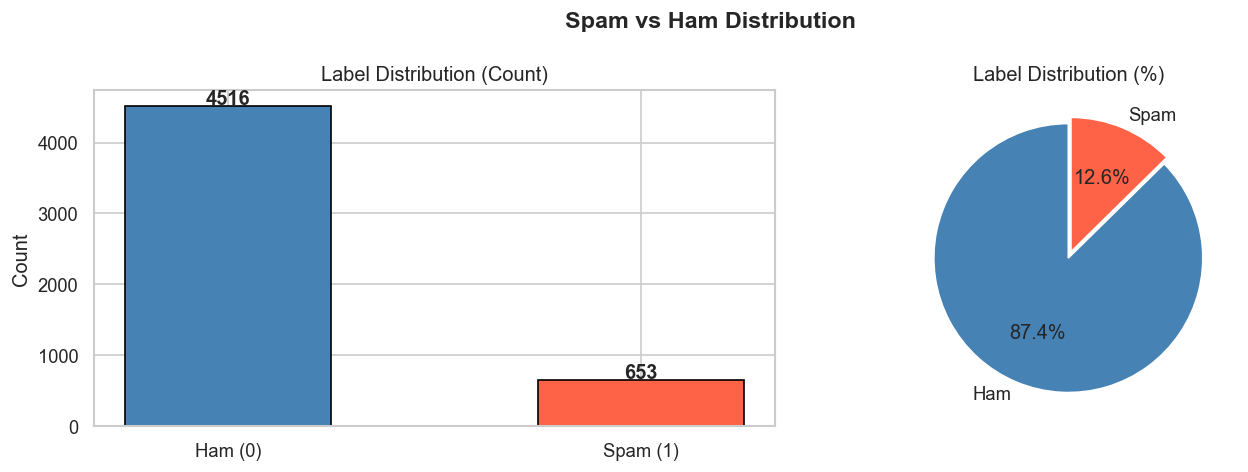

In [3]:
#Label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#Bar chart
counts = df["label"].value_counts()
axes[0].bar(["Ham (0)", "Spam (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="black", width=0.5)
axes[0].set_title("Label Distribution (Count)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

#Pie chart
axes[1].pie(counts.values,
            labels=["Ham", "Spam"],
            colors=["steelblue", "tomato"],
            autopct="%1.1f%%",
            startangle=90,
            explode=(0, 0.05))
axes[1].set_title("Label Distribution (%)")

plt.suptitle("Spam vs Ham Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

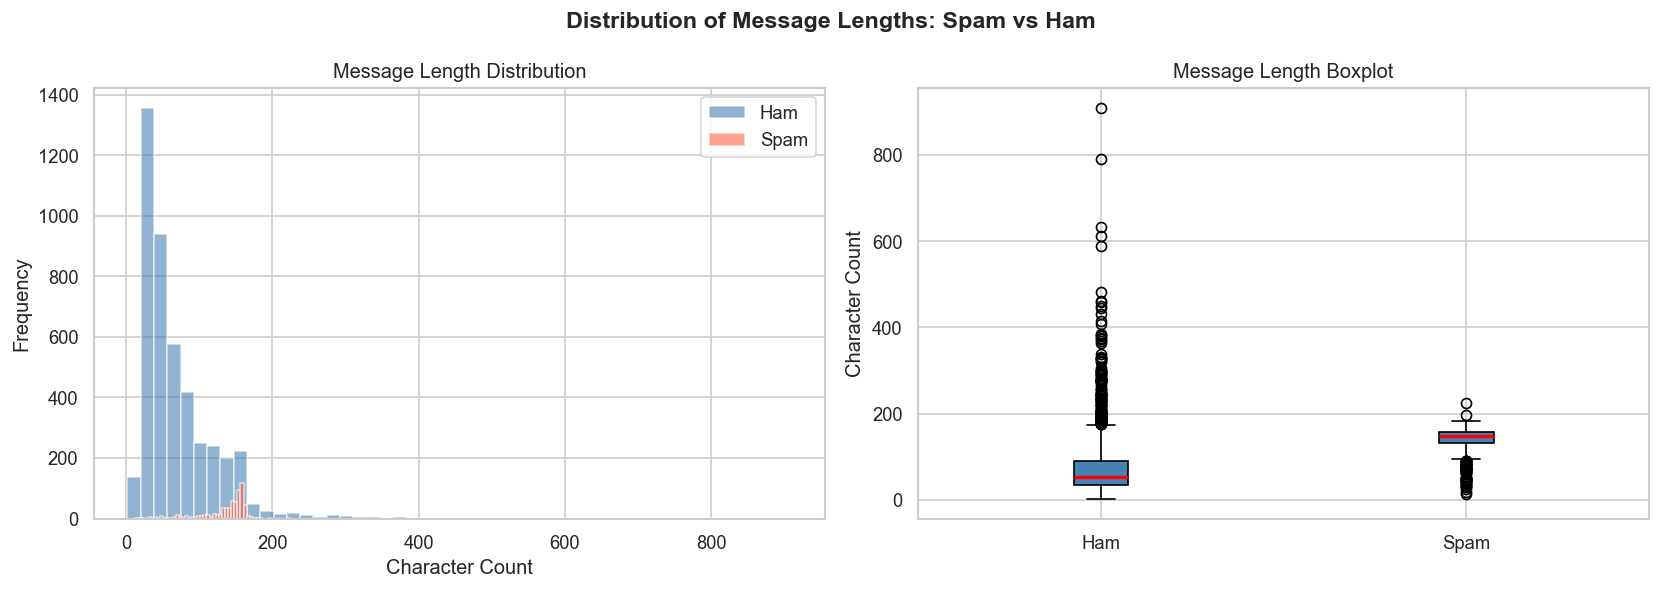

Average Message Length
             count   mean   std   min    25%    50%    75%    max
label_name                                                       
Ham         4516.0   70.5  56.4   2.0   34.0   52.0   90.0  910.0
Spam         653.0  137.9  30.1  13.0  132.0  149.0  157.0  224.0


In [4]:
# Distribution of message lengths (spam vs ham)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlapping
axes[0].hist(ham_df["text_length"],  bins=50, alpha=0.6,
             color="steelblue", label="Ham",  edgecolor="white")
axes[0].hist(spam_df["text_length"], bins=50, alpha=0.6,
             color="tomato",    label="Spam", edgecolor="white")
axes[0].set_title("Message Length Distribution")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot side by side
df["label_name"] = df["label"].map({0: "Ham", 1: "Spam"})
axes[1].boxplot(
    [ham_df["text_length"], spam_df["text_length"]],
    labels=["Ham", "Spam"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue"),
    medianprops=dict(color="red", linewidth=2)
)
axes[1].set_title("Message Length Boxplot")
axes[1].set_ylabel("Character Count")

plt.suptitle("Distribution of Message Lengths: Spam vs Ham",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# print summary statistics of message lengths by label
print("Average Message Length")
print(df.groupby("label_name")["text_length"].describe().round(1))

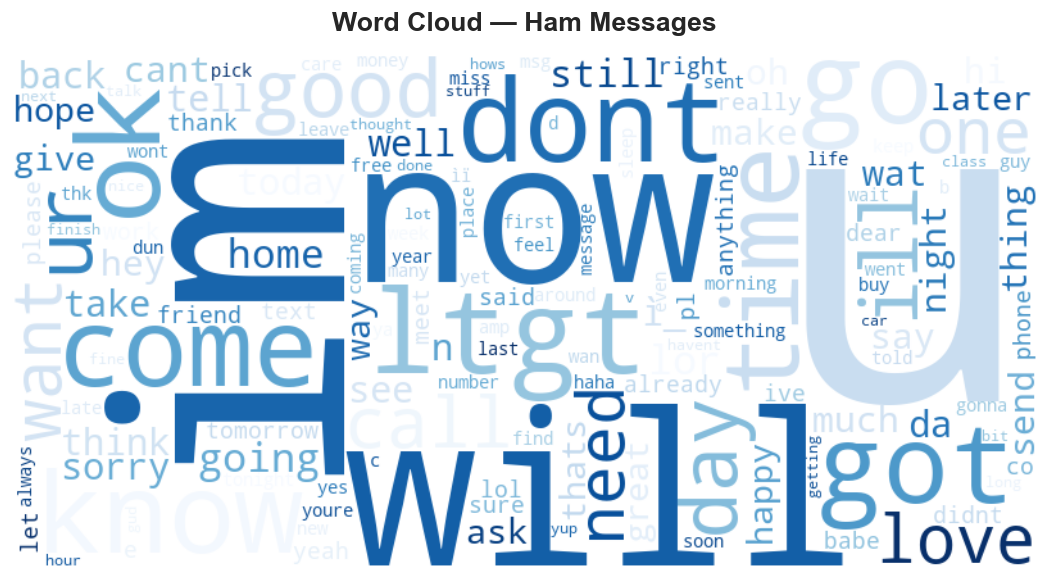

In [5]:
#Word Cloud - Ham messages
ham_text = " ".join(ham_df["text_clean"].dropna().tolist())

wordcloud_ham = WordCloud(
    width=800, height=400,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False
).generate(ham_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud_ham, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Ham Messages", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

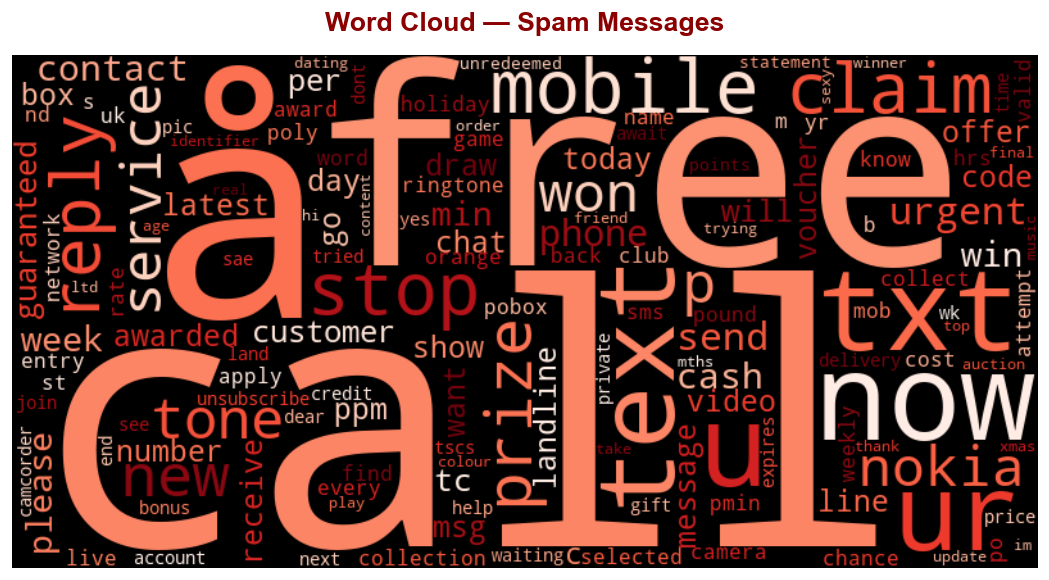

In [6]:
# CELL 6: Word Cloud - Spam messages
spam_text = " ".join(spam_df["text_clean"].dropna().tolist())

wordcloud_spam = WordCloud(
    width=800, height=400,
    background_color="black",
    colormap="Reds",
    max_words=150,
    collocations=False
).generate(spam_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud_spam, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Spam Messages", fontsize=16, fontweight="bold",
          color="darkred", pad=15)
plt.tight_layout()
plt.show()

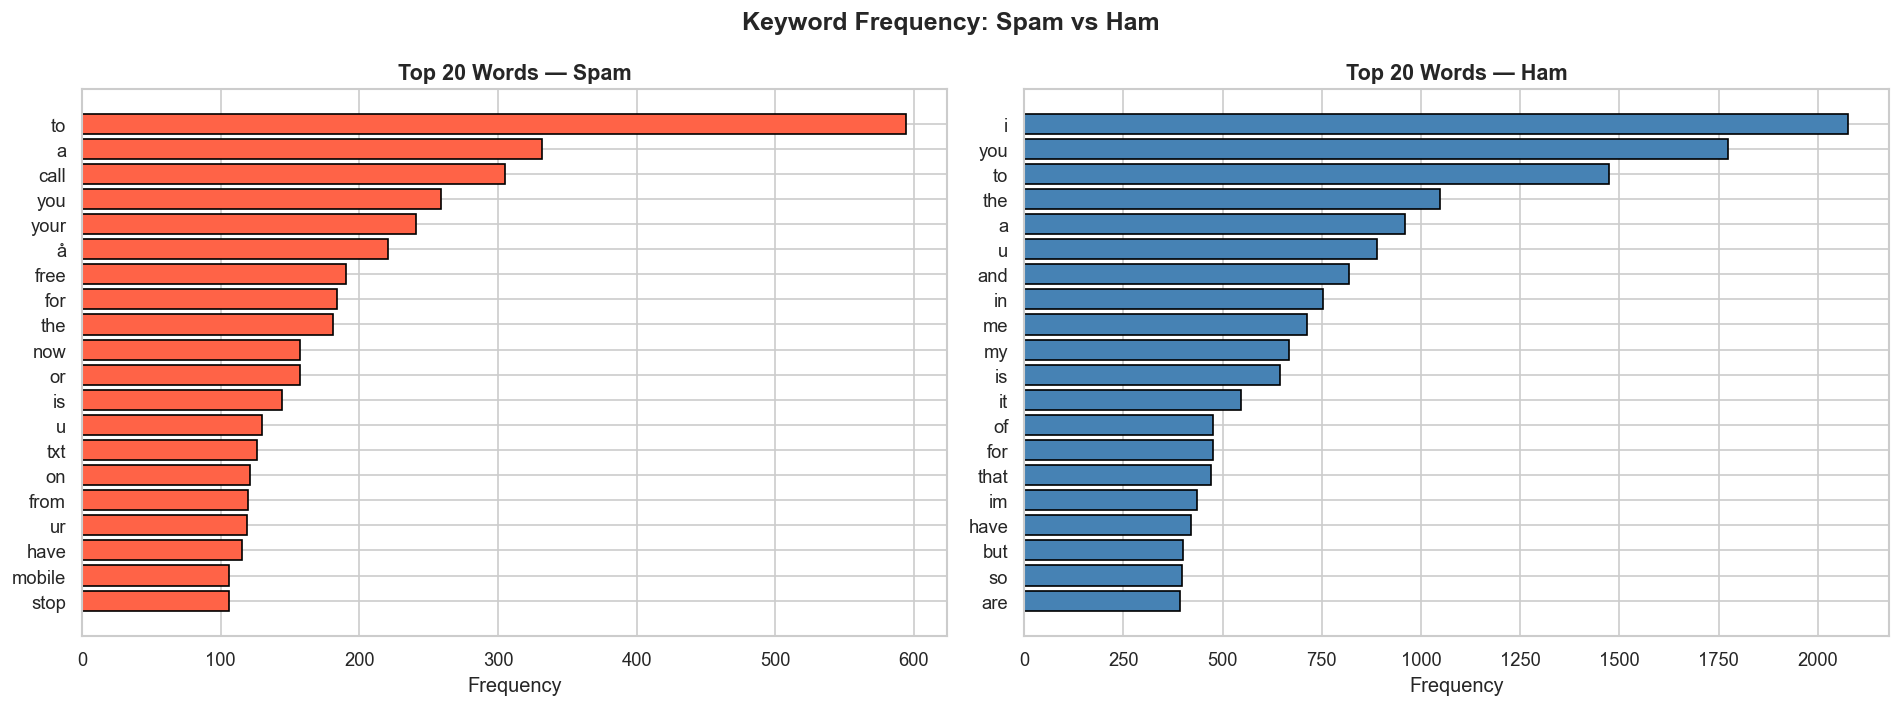

In [10]:
# Histogram of keyword frequencies (Top 20)

def get_top_words(text_series, n=20):
    all_words = " ".join(text_series.dropna()).split()
    return Counter(all_words).most_common(n)

top_spam = get_top_words(spam_df["text_clean"], 20)
top_ham  = get_top_words(ham_df["text_clean"],  20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# pam top words
words_s, counts_s = zip(*top_spam)
axes[0].barh(list(words_s)[::-1], list(counts_s)[::-1],
             color="tomato", edgecolor="black")
axes[0].set_title("Top 20 Words — Spam", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Frequency")

# Ham top words 
words_h, counts_h = zip(*top_ham)
axes[1].barh(list(words_h)[::-1], list(counts_h)[::-1],
             color="steelblue", edgecolor="black")
axes[1].set_title("Top 20 Words — Ham", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Frequency")

plt.suptitle("Keyword Frequency: Spam vs Ham",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

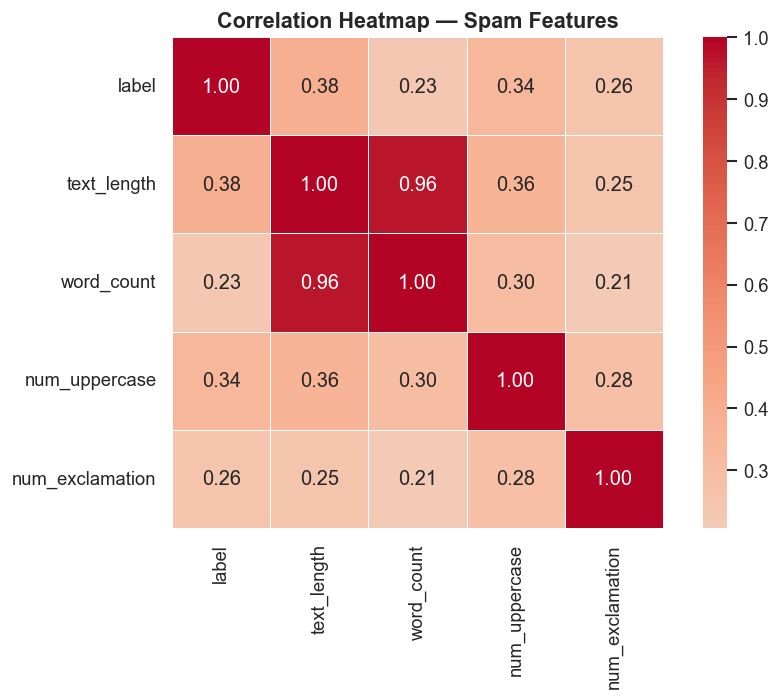

In [11]:
# Correlation heatmap of auxiliary features
features = ["label", "text_length", "word_count",
            "num_uppercase", "num_exclamation"]

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Spam Features",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()